#1. Import Library

In [ ]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import librosa
import librosa.display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import joblib

%matplotlib inline

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


#2. Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


#3. Load Dataset

In [ ]:
DATASET_PATH = "/content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Data/genres_original"

genres = sorted([g for g in os.listdir(DATASET_PATH)
                 if os.path.isdir(os.path.join(DATASET_PATH, g))])

print("Genre yang ditemukan:")
print(genres)

Genre yang ditemukan:
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
audio_files = []
labels = []

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    wav_files = sorted(glob.glob(os.path.join(genre_path, "*.wav")))

    for file_path in wav_files:
        audio_files.append(file_path)
        labels.append(genre)

print(f"Total file audio ditemukan: {len(audio_files)}")

Total file audio ditemukan: 1000


#4. Visualisasi Dataset

Jumlah file per genre:
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


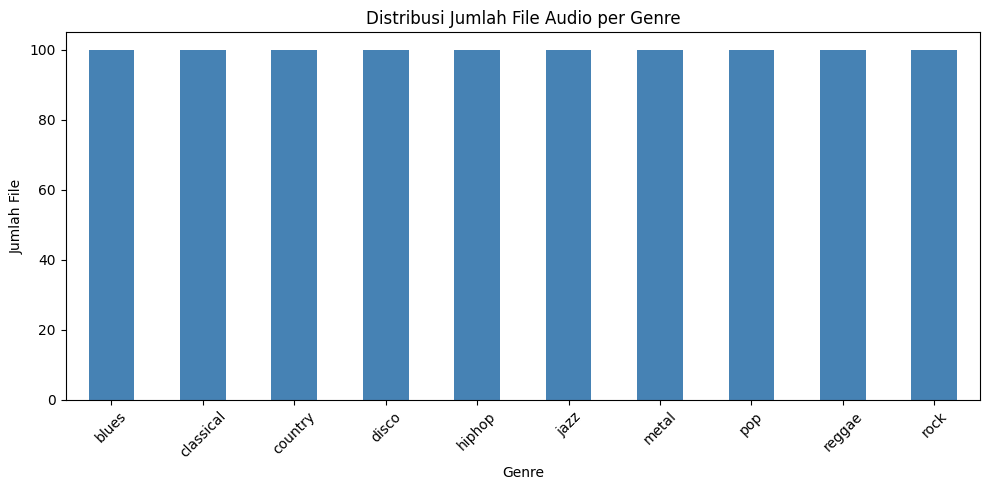

In [ ]:
dataset_df = pd.DataFrame({"file_path": audio_files, "genre": labels})

print("Jumlah file per genre:")
print(dataset_df["genre"].value_counts())

plt.figure(figsize=(10, 5))
dataset_df["genre"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Distribusi Jumlah File Audio per Genre")
plt.xlabel("Genre")
plt.ylabel("Jumlah File")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Properti audio dari salah satu file sampel
sample_path = audio_files[0]
y_sample, sr_sample = librosa.load(sample_path, sr=None)
duration = librosa.get_duration(y=y_sample, sr=sr_sample)

print(f"File sampel   : {sample_path}")
print(f"Sample rate   : {sr_sample} Hz")
print(f"Durasi audio  : {duration:.2f} detik")

File sampel   : /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Data/genres_original/blues/blues.00000.wav
Sample rate   : 22050 Hz
Durasi audio  : 30.01 detik


#5. Visualisasi Waveform

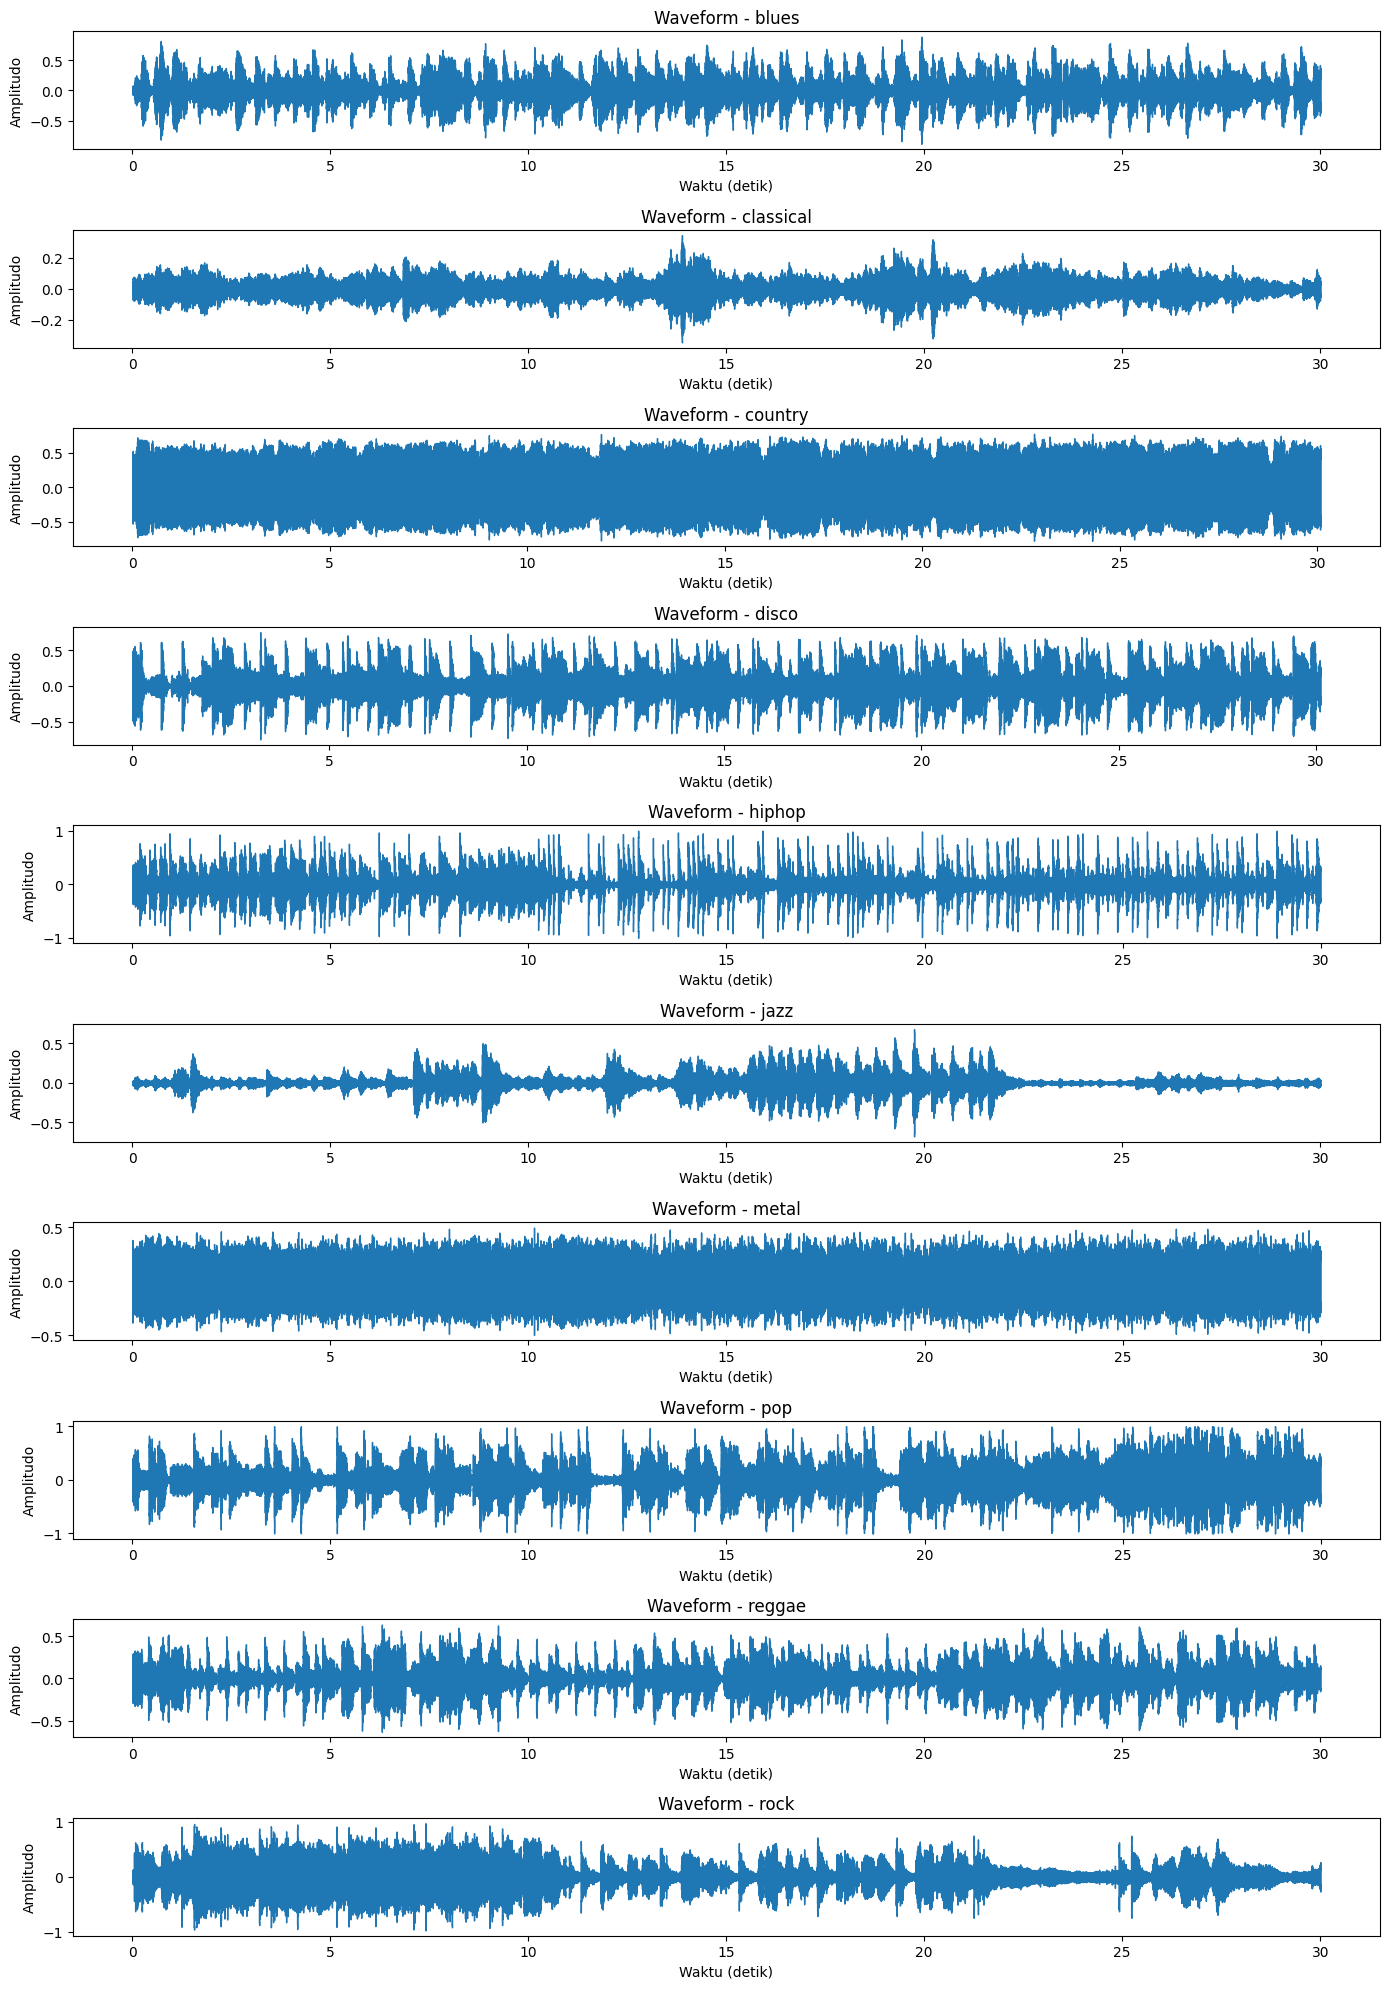

In [ ]:
sample_per_genre = dataset_df.groupby("genre")["file_path"].first()

plt.figure(figsize=(14, 20))
for i, (genre, path) in enumerate(sample_per_genre.items()):
    y, sr = librosa.load(path, sr=22050)

    plt.subplot(len(sample_per_genre), 1, i + 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {genre}")
    plt.xlabel("Waktu (detik)")
    plt.ylabel("Amplitudo")

plt.tight_layout()
plt.show()

#6. Visualisasi Mel Spectrogram

In [ ]:
plt.figure(figsize=(14, 20))
for i, (genre, path) in enumerate(sample_per_genre.items()):
    y, sr = librosa.load(path, sr=22050)

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.subplot(len(sample_per_genre), 1, i + 1)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(f"Mel-Spectrogram - {genre}")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#7. Feature Extraction

In [ ]:
def extract_features_from_segment(y, sr, n_mfcc=20):

    features = {}

    # 1. MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    for i in range(n_mfcc):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

    # 2. Delta MFCC
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    for i in range(n_mfcc):
        features[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfcc[i])
        features[f"delta_mfcc_{i+1}_std"] = np.std(delta_mfcc[i])

    # 3. Delta-Delta MFCC
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)
    for i in range(n_mfcc):
        features[f"delta2_mfcc_{i+1}_mean"] = np.mean(delta2_mfcc[i])
        features[f"delta2_mfcc_{i+1}_std"] = np.std(delta2_mfcc[i])

    # 4. Spectral Centroid
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["spectral_centroid_mean"] = np.mean(spec_centroid)
    features["spectral_centroid_std"] = np.std(spec_centroid)

    # 5. Spectral Bandwidth
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features["spectral_bandwidth_mean"] = np.mean(spec_bandwidth)
    features["spectral_bandwidth_std"] = np.std(spec_bandwidth)

    # 6. Spectral Roll-off
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features["spectral_rolloff_mean"] = np.mean(spec_rolloff)
    features["spectral_rolloff_std"] = np.std(spec_rolloff)

    # 7. Spectral Contrast
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    for i in range(spec_contrast.shape[0]):
        features[f"spectral_contrast_{i+1}_mean"] = np.mean(spec_contrast[i])
        features[f"spectral_contrast_{i+1}_std"] = np.std(spec_contrast[i])

    # 8. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y=y)
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"] = np.std(zcr)

    # 9. Chroma STFT
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    for i in range(chroma.shape[0]):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
        features[f"chroma_{i+1}_std"] = np.std(chroma[i])

    # 10. RMS Energy
    rms = librosa.feature.rms(y=y)
    features["rms_mean"] = np.mean(rms)
    features["rms_std"] = np.std(rms)

    # 11. Tempo (menggunakan tempogram agar diperoleh beberapa nilai per segmen)
    try:
        tempo_frames = librosa.feature.tempo(y=y, sr=sr, aggregate=None)
        features["tempo_mean"] = np.mean(tempo_frames)
        features["tempo_std"] = np.std(tempo_frames)
    except Exception:
        # Fallback: jika segmen terlalu pendek untuk estimasi tempo dinamis
        tempo_value = librosa.feature.tempo(y=y, sr=sr, aggregate=np.mean)
        features["tempo_mean"] = float(np.atleast_1d(tempo_value)[0])
        features["tempo_std"] = 0.0

    return features


print("Fungsi extract_features_from_segment() berhasil didefinisikan.")

Fungsi extract_features_from_segment() berhasil didefinisikan.


#8. Segmentasi Audio

In [ ]:
SEGMENT_DURATION = 3  # detik
SAMPLE_RATE = 22050


def segment_audio(y, sr, segment_duration=SEGMENT_DURATION):
    """
    Memecah sinyal audio menjadi beberapa segmen dengan durasi tetap.
    Sisa sinyal yang lebih pendek dari segment_duration diabaikan.
    """
    segment_length = int(segment_duration * sr)
    n_segments = len(y) // segment_length

    segments = [
        y[i * segment_length : (i + 1) * segment_length]
        for i in range(n_segments)
    ]
    return segments


def process_audio_file(file_path, sr=SAMPLE_RATE, segment_duration=SEGMENT_DURATION):
    """
    Memuat satu file audio, memecahnya menjadi beberapa segmen,
    lalu mengekstrak fitur dari tiap segmen.

    Returns
    -------
    list of dict
        Satu dict fitur untuk tiap segmen yang berhasil diproses.
    """
    y, sr = librosa.load(file_path, sr=sr)
    segments = segment_audio(y, sr, segment_duration)

    segment_features_list = []
    for seg_idx, y_seg in enumerate(segments):
        feat_dict = extract_features_from_segment(y_seg, sr)
        feat_dict["segment_index"] = seg_idx
        segment_features_list.append(feat_dict)

    return segment_features_list


# Uji fungsi segmentasi pada satu file sampel
test_segments = segment_audio(
    librosa.load(audio_files[0], sr=SAMPLE_RATE)[0], SAMPLE_RATE
)
print(f"File sampel dipecah menjadi {len(test_segments)} segmen berdurasi {SEGMENT_DURATION} detik.")

File sampel dipecah menjadi 10 segmen berdurasi 3 detik.


#9. Membuat `features.csv`

In [ ]:
all_rows = []
failed_files = []

print("Memulai proses ekstraksi fitur (dengan segmentasi 3 detik) untuk seluruh dataset...\n")

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    wav_files = sorted(glob.glob(os.path.join(genre_path, "*.wav")))

    print(f"Memproses genre: {genre:10s} | Jumlah file: {len(wav_files)}")

    success_count = 0
    fail_count = 0
    segment_count = 0

    for file_path in wav_files:
        try:
            segment_features_list = process_audio_file(file_path)

            for feat_dict in segment_features_list:
                feat_dict["filename"] = os.path.basename(file_path)
                feat_dict["label"] = genre
                all_rows.append(feat_dict)

            segment_count += len(segment_features_list)
            success_count += 1

        except Exception as e:
            fail_count += 1
            failed_files.append({"file_path": file_path, "genre": genre, "error": str(e)})

    print(f"   -> File berhasil: {success_count} | File gagal: {fail_count} | Total segmen: {segment_count}\n")

print("Ekstraksi fitur seluruh dataset selesai.")
print(f"Total baris (segmen) berhasil diekstrak : {len(all_rows)}")
print(f"Total file gagal diproses                : {len(failed_files)}")

Memulai proses ekstraksi fitur (dengan segmentasi 3 detik) untuk seluruh dataset...

Memproses genre: blues      | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 1000

Memproses genre: classical  | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 998

Memproses genre: country    | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 997

Memproses genre: disco      | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 999

Memproses genre: hiphop     | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 998

Memproses genre: jazz       | Jumlah file: 100
   -> File berhasil: 99 | File gagal: 1 | Total segmen: 990

Memproses genre: metal      | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 1000

Memproses genre: pop        | Jumlah file: 100
   -> File berhasil: 100 | File gagal: 0 | Total segmen: 1000

Memproses genre: reggae     | Jumlah file

In [ ]:
# Menampilkan daftar file yang gagal diproses (jika ada)
failed_df = pd.DataFrame(failed_files)

if len(failed_df) > 0:
    print(f"Ditemukan {len(failed_df)} file yang gagal diproses:")
    display(failed_df)
else:
    print("Tidak ada file yang gagal diproses. Semua file berhasil diekstrak.")

Ditemukan 1 file yang gagal diproses:


,file_path,genre,error
0,/content/drive/My Drive/SEMESTER 4/PPDM/Final ...,jazz,


In [ ]:
# Menyusun seluruh hasil menjadi satu DataFrame
features_df = pd.DataFrame(all_rows)

# Menempatkan kolom filename, segment_index, dan label di posisi awal agar rapi
front_cols = ["filename", "segment_index", "label"]
other_cols = [c for c in features_df.columns if c not in front_cols]
features_df = features_df[front_cols + other_cols]

print(f"Ukuran DataFrame hasil ekstraksi: {features_df.shape[0]} baris x {features_df.shape[1]} kolom")
features_df.head()

Ukuran DataFrame hasil ekstraksi: 9981 baris x 173 kolom


,filename,segment_index,label,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,...,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,rms_mean,rms_std,tempo_mean,tempo_std
0,blues.00000.wav,0,blues,-119.018044,49.944424,125.080353,16.189907,-23.394333,19.115284,41.321732,...,0.337069,0.317082,0.347898,0.328560,0.344555,0.282362,0.130189,0.059656,129.199219,0.0
1,blues.00000.wav,1,blues,-125.977150,45.241447,122.374191,14.780329,-20.679749,15.271171,50.035046,...,0.262002,0.273579,0.339586,0.307686,0.370314,0.318054,0.112119,0.038616,123.046875,0.0
2,blues.00000.wav,2,blues,-132.618149,61.601986,114.815521,15.709209,-14.718568,13.891207,50.017944,...,0.359410,0.268566,0.494625,0.350773,0.369133,0.230604,0.130895,0.067469,123.046875,0.0
3,blues.00000.wav,3,blues,-118.325325,50.058475,131.587173,17.984241,-18.493637,10.475515,39.478859,...,0.286163,0.255670,0.423766,0.317565,0.421856,0.301698,0.131349,0.048356,123.046875,0.0
4,blues.00000.wav,4,blues,-106.182114,46.093063,134.275955,14.477101,-19.761965,13.183636,39.920502,...,0.274796,0.264650,0.495465,0.375106,0.365276,0.274020,0.142370,0.041644,123.046875,0.0


In [ ]:
# Menyimpan hasil ekstraksi ke Google Drive
FEATURES_CSV_PATH = "/content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/features.csv"

features_df.to_csv(FEATURES_CSV_PATH, index=False)

print(f"features.csv berhasil disimpan di: {FEATURES_CSV_PATH}")

features.csv berhasil disimpan di: /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/features.csv


#10. Load `features.csv`

In [ ]:
FEATURES_CSV_PATH = "/content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/features.csv"

features_df = pd.read_csv(FEATURES_CSV_PATH)

print(f"Ukuran dataset: {features_df.shape[0]} baris x {features_df.shape[1]} kolom")
print(f"\nDistribusi label genre:")
print(features_df["label"].value_counts())

features_df.head()

Ukuran dataset: 9981 baris x 173 kolom

Distribusi label genre:
label
blues        1000
pop          1000
metal        1000
reggae       1000
rock          999
disco         999
classical     998
hiphop        998
country       997
jazz          990
Name: count, dtype: int64


,filename,segment_index,label,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,...,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,rms_mean,rms_std,tempo_mean,tempo_std
0,blues.00000.wav,0,blues,-119.018040,49.944424,125.08035,16.189907,-23.394333,19.115284,41.321730,...,0.337069,0.317082,0.347898,0.328560,0.344555,0.282362,0.130189,0.059656,129.199219,0.0
1,blues.00000.wav,1,blues,-125.977150,45.241447,122.37419,14.780329,-20.679749,15.271171,50.035046,...,0.262002,0.273579,0.339586,0.307686,0.370314,0.318054,0.112119,0.038616,123.046875,0.0
2,blues.00000.wav,2,blues,-132.618150,61.601986,114.81552,15.709209,-14.718568,13.891207,50.017944,...,0.359410,0.268566,0.494625,0.350773,0.369133,0.230604,0.130895,0.067469,123.046875,0.0
3,blues.00000.wav,3,blues,-118.325325,50.058475,131.58717,17.984241,-18.493637,10.475515,39.478860,...,0.286163,0.255670,0.423766,0.317565,0.421856,0.301698,0.131349,0.048356,123.046875,0.0
4,blues.00000.wav,4,blues,-106.182110,46.093063,134.27596,14.477101,-19.761965,13.183636,39.920500,...,0.274796,0.264650,0.495465,0.375106,0.365276,0.274020,0.142370,0.041644,123.046875,0.0


In [ ]:
# Memisahkan fitur (X) dan label (y)
feature_columns = [c for c in features_df.columns if c not in ["filename", "segment_index", "label"]]

X = features_df[feature_columns]
y = features_df["label"]

print(f"Jumlah fitur sebelum seleksi : {X.shape[1]}")
print(f"Jumlah sampel (segmen)       : {X.shape[0]}")

Jumlah fitur sebelum seleksi : 170
Jumlah sampel (segmen)       : 9981


#11. Feature Selection

In [ ]:
# Label Encoding (dibutuhkan oleh ANOVA F-test dan model SVM)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Pemetaan label genre ke angka:")
for i, genre_name in enumerate(label_encoder.classes_):
    print(f"  {genre_name:10s} -> {i}")

Pemetaan label genre ke angka:
  blues      -> 0
  classical  -> 1
  country    -> 2
  disco      -> 3
  hiphop     -> 4
  jazz       -> 5
  metal      -> 6
  pop        -> 7
  reggae     -> 8
  rock       -> 9


In [ ]:
# Stratified Train-Test Split (dilakukan sebelum feature selection untuk mencegah data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f"Jumlah data latih (train) : {X_train.shape[0]}")
print(f"Jumlah data uji (test)    : {X_test.shape[0]}")

Jumlah data latih (train) : 7984
Jumlah data uji (test)    : 1997


In [ ]:
# Feature Selection menggunakan SelectKBest dengan ANOVA F-test
K_BEST = 60  # jumlah fitur terbaik yang dipilih (dapat disesuaikan)

selector = SelectKBest(score_func=f_classif, k=K_BEST)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Menampilkan nama fitur yang terpilih beserta skor F-nya
selected_mask = selector.get_support()
selected_feature_names = X_train.columns[selected_mask]

feature_scores_df = pd.DataFrame({
    "feature_name": X_train.columns,
    "f_score": selector.scores_
}).sort_values("f_score", ascending=False)

print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]} dari {X_train.shape[1]} fitur awal")
print(f"\n10 fitur dengan skor F-test tertinggi:")
feature_scores_df.head(10)

Jumlah fitur setelah seleksi: 60 dari 170 fitur awal

10 fitur dengan skor F-test tertinggi:


,feature_name,f_score
132,spectral_contrast_4_mean,920.312052
134,spectral_contrast_5_mean,917.519309
122,spectral_bandwidth_mean,837.750295
0,mfcc_1_mean,834.296768
124,spectral_rolloff_mean,770.114776
81,delta2_mfcc_1_std,727.563273
121,spectral_centroid_std,708.168552
87,delta2_mfcc_4_std,693.103916
167,rms_std,689.173052
120,spectral_centroid_mean,659.421626


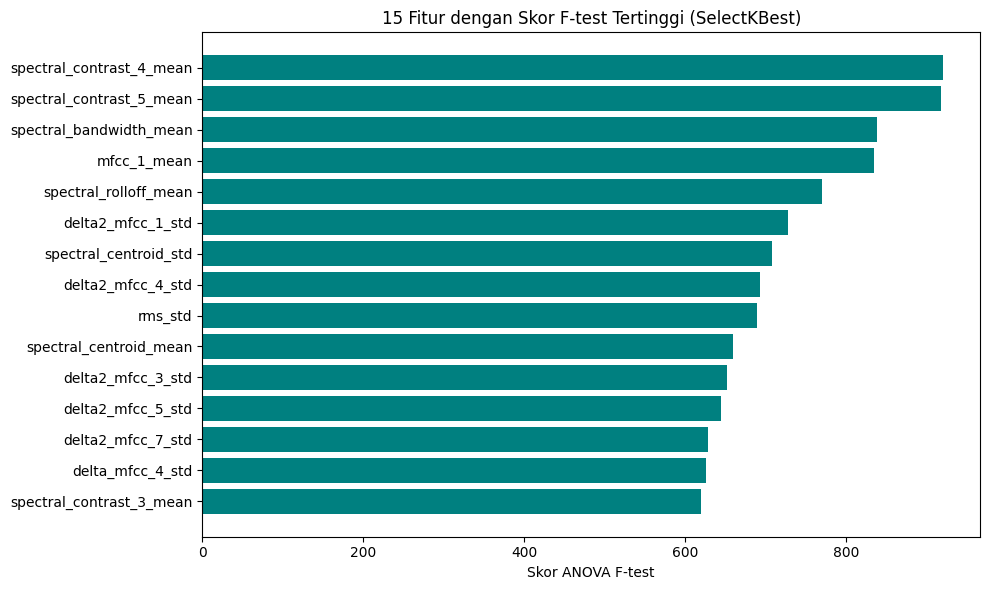

In [ ]:
# Visualisasi 15 fitur dengan skor F-test tertinggi
top_features = feature_scores_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature_name"][::-1], top_features["f_score"][::-1], color="teal")
plt.xlabel("Skor ANOVA F-test")
plt.title("15 Fitur dengan Skor F-test Tertinggi (SelectKBest)")
plt.tight_layout()
plt.show()

#12. Preprocessing (Standardisasi Fitur)

In [ ]:
scaler = StandardScaler()

X_train_final = scaler.fit_transform(X_train_selected)
X_test_final = scaler.transform(X_test_selected)

print("Standardisasi fitur selesai.")
print(f"Bentuk X_train_final : {X_train_final.shape}")
print(f"Bentuk X_test_final  : {X_test_final.shape}")

Standardisasi fitur selesai.
Bentuk X_train_final : (7984, 60)
Bentuk X_test_final  : (1997, 60)


#13. Training SVM (Model Awal)

In [ ]:
svm_baseline = SVC(kernel="rbf", random_state=42)
svm_baseline.fit(X_train_final, y_train)

y_pred_baseline = svm_baseline.predict(X_test_final)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Training SVM baseline selesai.")
print(f"Accuracy model baseline (parameter default): {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")

Training SVM baseline selesai.
Accuracy model baseline (parameter default): 0.8468 (84.68%)


#14. Hyperparameter Tuning menggunakan `GridSearchCV`

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100, 500, 1000],
    "gamma": ["scale", 1, 0.1, 0.01, 0.001, 0.0001],
    "kernel": ["rbf"]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_final, y_train)

print("\nGridSearchCV selesai.")

Fitting 5 folds for each of 42 candidates, totalling 210 fits

GridSearchCV selesai.


In [ ]:
print("Parameter terbaik hasil GridSearchCV:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:10s} : {value}")

print(f"\nBest F1-Macro (cross-validation): {grid_search.best_score_:.4f}")

# Model SVM terbaik hasil tuning
best_svm_model = grid_search.best_estimator_

Parameter terbaik hasil GridSearchCV:
  C          : 10
  gamma      : scale
  kernel     : rbf

Best F1-Macro (cross-validation): 0.9038


In [ ]:
# Cross validation ulang pada model hasil tuning, sebagai verifikasi konsistensi performa
cv_scores_tuned = cross_val_score(
    best_svm_model, X_train_final, y_train,
    cv=cv_strategy, scoring="accuracy", n_jobs=-1
)

print("Cross-Validation Accuracy - Model SVM Setelah Tuning (5-fold):")
print(cv_scores_tuned)
print(f"\nRata-rata  : {cv_scores_tuned.mean():.4f}")
print(f"Std. Dev.  : {cv_scores_tuned.std():.4f}")

Cross-Validation Accuracy - Model SVM Setelah Tuning (5-fold):
[0.89542893 0.90231684 0.90795241 0.90670006 0.90789474]

Rata-rata  : 0.9041
Std. Dev.  : 0.0048


#15. Evaluasi Model

In [ ]:
y_pred_tuned = best_svm_model.predict(X_test_final)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average="macro")
recall_tuned = recall_score(y_test, y_pred_tuned, average="macro")
f1_tuned = f1_score(y_test, y_pred_tuned, average="macro")

print("Hasil Evaluasi Model SVM (Setelah Tuning)")
print("-" * 45)
print(f"Accuracy  : {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")
print(f"Precision : {precision_tuned:.4f} ({precision_tuned*100:.2f}%)")
print(f"Recall    : {recall_tuned:.4f} ({recall_tuned*100:.2f}%)")
print(f"F1 Score  : {f1_tuned:.4f} ({f1_tuned*100:.2f}%)")

print(f"\nPerbandingan dengan model baseline:")
print(f"  Accuracy Baseline       : {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"  Accuracy Setelah Tuning : {accuracy_tuned:.4f} ({accuracy_tuned*100:.2f}%)")

Hasil Evaluasi Model SVM (Setelah Tuning)
---------------------------------------------
Accuracy  : 0.9129 (91.29%)
Precision : 0.9127 (91.27%)
Recall    : 0.9129 (91.29%)
F1 Score  : 0.9124 (91.24%)

Perbandingan dengan model baseline:
  Accuracy Baseline       : 0.8468 (84.68%)
  Accuracy Setelah Tuning : 0.9129 (91.29%)


In [ ]:
report_tuned = classification_report(
    y_test, y_pred_tuned,
    target_names=label_encoder.classes_
)

print("Classification Report (Model SVM Setelah Tuning):\n")
print(report_tuned)

Classification Report (Model SVM Setelah Tuning):

              precision    recall  f1-score   support

       blues       0.90      0.92      0.91       200
   classical       0.95      0.98      0.97       200
     country       0.86      0.84      0.85       199
       disco       0.88      0.91      0.89       200
      hiphop       0.95      0.94      0.94       200
        jazz       0.91      0.97      0.94       198
       metal       0.94      0.97      0.96       200
         pop       0.96      0.90      0.93       200
      reggae       0.92      0.90      0.91       200
        rock       0.86      0.80      0.83       200

    accuracy                           0.91      1997
   macro avg       0.91      0.91      0.91      1997
weighted avg       0.91      0.91      0.91      1997



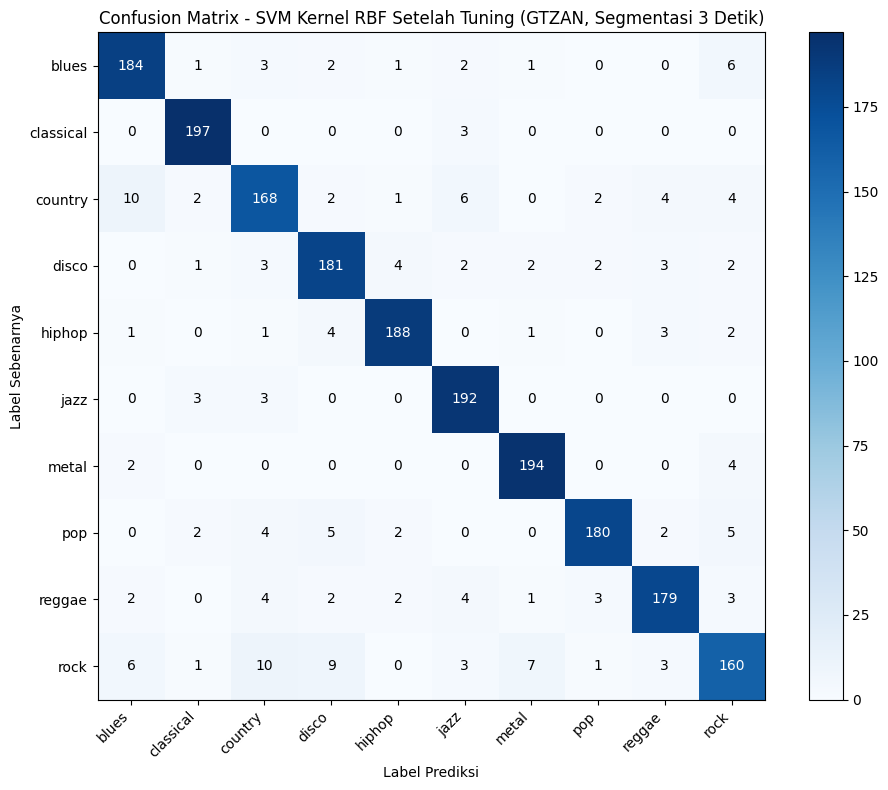

In [ ]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(10, 8))
im = plt.imshow(cm_tuned, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix - SVM Kernel RBF Setelah Tuning (GTZAN, Segmentasi 3 Detik)")
plt.colorbar(im)

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, label_encoder.classes_)

thresh = cm_tuned.max() / 2.0
for i in range(cm_tuned.shape[0]):
    for j in range(cm_tuned.shape[1]):
        plt.text(
            j, i, format(cm_tuned[i, j], "d"),
            ha="center", va="center",
            color="white" if cm_tuned[i, j] > thresh else "black"
        )

plt.ylabel("Label Sebenarnya")
plt.xlabel("Label Prediksi")
plt.tight_layout()
plt.show()

In [ ]:
# Ringkasan perbandingan baseline vs tuning dalam bentuk tabel
summary_df = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Baseline (default params)": [baseline_accuracy, np.nan, np.nan, np.nan],
    "Setelah Tuning (GridSearchCV)": [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned]
})

print("Ringkasan Perbandingan Performa Model:")
summary_df

Ringkasan Perbandingan Performa Model:


,Metrik,Baseline (default params),Setelah Tuning (GridSearchCV)
0,Accuracy,0.84677,0.912869
1,Precision,NaN,0.912657
2,Recall,NaN,0.912892
3,F1 Score,NaN,0.912362


#16. Save Model

In [ ]:
OUTPUT_DIR = "/content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output"

joblib.dump(best_svm_model, os.path.join(OUTPUT_DIR, "svm_model.pkl"))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "scaler.pkl"))
joblib.dump(label_encoder, os.path.join(OUTPUT_DIR, "label_encoder.pkl"))
joblib.dump(
    {"selector": selector, "selected_feature_names": list(selected_feature_names)},
    os.path.join(OUTPUT_DIR, "selected_features.pkl")
)

print("Seluruh file berhasil disimpan ke Google Drive:")
print(f"  - {os.path.join(OUTPUT_DIR, 'svm_model.pkl')}")
print(f"  - {os.path.join(OUTPUT_DIR, 'scaler.pkl')}")
print(f"  - {os.path.join(OUTPUT_DIR, 'label_encoder.pkl')}")
print(f"  - {os.path.join(OUTPUT_DIR, 'selected_features.pkl')}")

Seluruh file berhasil disimpan ke Google Drive:
  - /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/svm_model.pkl
  - /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/scaler.pkl
  - /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/label_encoder.pkl
  - /content/drive/My Drive/SEMESTER 4/PPDM/Final Project/Identifikasi Genre Musik Berdasarkan Karakteristik Spektral Audio/Output/selected_features.pkl
